# AA200 Problem Set 4 — Problem 1
## Thwaites' (Laminar) and Head's (Turbulent) Integral Boundary Layer Methods
### Flat Plate, Zero Pressure Gradient, Re_L = 1×10⁶

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({'figure.dpi': 120, 'font.size': 12,
                     'lines.linewidth': 2, 'axes.grid': True,
                     'grid.alpha': 0.35})

---
## 1. Problem Setup

Flat plate of length $L=1$ m, $V_e = V_\infty =$ const (since there is no pressure gradient the derivative of $V_e$ is also nul ), $\mathrm{Re}_L = \rho V_\infty L/\mu = 10^6$.

In [15]:
# --- Physical parameters ---
Re_L   = 1e6          # Reynolds number based on plate length
L      = 1.0          # plate length [m], we use this to work in terms of non-dimensional x/L
Ve     = 1.0          # edge velocity (normalised so we are working in terms of non-dimensional velocity)
nu     = Ve * L / Re_L  # kinematic viscosity

# Spatial grid: avoid x=0 singularity by starting slightly off the LE
N  = 2000
x  = np.linspace(1e-6, L, N)    # dimensional (= x/L since L=1)
Re_x = Ve * x / nu              # local Reynolds number

print(f"nu = {nu:.3e}   Re_L = {Ve*L/nu:.3e}")

nu = 1.000e-06   Re_L = 1.000e+06


---
## 2. Blasius Reference Solution

Exact similarity solution for laminar flat plate:
$$\frac{\theta}{x} = \frac{0.664}{\sqrt{\mathrm{Re}_x}}, \quad
  \frac{\delta^*}{x} = \frac{1.7208}{\sqrt{\mathrm{Re}_x}}, \quad
  H = \frac{\delta^*}{\theta} = 2.591, \quad
  c_f = \frac{0.664}{\sqrt{\mathrm{Re}_x}}$$
$$C_f = \frac{1.328}{\sqrt{\mathrm{Re}_L}}$$

In [16]:
# ---- Blasius ----
theta_blasius  = 0.664  * x / np.sqrt(Re_x)
dstar_blasius  = 1.7208 * x / np.sqrt(Re_x)
H_blasius      = np.full_like(x, 2.591)
cf_blasius     = 0.664  / np.sqrt(Re_x)

# Integrated skin-friction coefficient
Cf_blasius = 1.328 / np.sqrt(Re_L)
print(f"Blasius  Cf = {Cf_blasius:.6f}")

Blasius  Cf = 0.001328


---
## 3. Thwaites' Method (Laminar)

### Key equations from (Moran §7.5)

The momentum thickness ODE in dimensionless form (constant $V_e$, zero PG):
$$\frac{d}{dx}(\theta^2 V_e^6) = 0.45\,\nu\,V_e^5
  \quad\Longrightarrow\quad
  \theta^2 = \frac{0.45\,\nu}{V_e^6}\int_0^x V_e^5\,dx'$$

For constant $V_e$: $\theta = \sqrt{0.45\,\nu x / V_e}$

Pressure-gradient parameter:
$$\lambda = \frac{\theta^2}{\nu}\frac{dV_e}{dx}$$

Correlation function:
$$l(\lambda):\quad
\begin{cases}
0.22+1.57\lambda-1.8\lambda^2 & 0<\lambda<0.1\\
0.22+1.402\lambda+\dfrac{0.018\lambda}{\lambda+0.107} & -0.1<\lambda\le 0
\end{cases}$$
$$H(\lambda):\quad
\begin{cases}
2.61-3.75\lambda+5.24\lambda^2 & 0<\lambda<0.1\\
2.088+\dfrac{0.0731}{\lambda+0.14} & -0.1<\lambda\le 0
\end{cases}$$
$$c_f = \frac{2\,l}{\mathrm{Re}_\theta}$$

Separation criterion: $\lambda < -0.0842$.

In [17]:
# ---- Thwaites correlation functions  ----

def thwaites_l(lam):
    """Thwaites l(lambda) """
    if lam >= 0.0:
        return 0.22 + 1.57*lam - 1.8*lam**2
    else:  # -0.1 <= lam < 0
        return 0.22 + 1.402*lam + 0.018*lam/(lam + 0.107)

def thwaites_H(lam):
    """Thwaites H(lambda) -"""
    if lam >= 0.0:
        return 2.61 - 3.75*lam + 5.24*lam**2
    else:
        return 2.088 + 0.0731/(lam + 0.14)

thwaites_l = np.vectorize(thwaites_l)
thwaites_H = np.vectorize(thwaites_H)

# ---- Thwaites integration: constant Ve (zero PG) ----
# Analytical: theta^2 = 0.45*nu*x / Ve  (Ve=1)
theta2_thw  = 0.45 * nu * x / Ve
theta_thw   = np.sqrt(theta2_thw)

# lambda = theta^2/nu * dVe/dx  => 0 for flat plate
lam_thw = np.zeros_like(x)    # dVe/dx = 0

H_thw   = thwaites_H(lam_thw)
l_thw   = thwaites_l(lam_thw)
dstar_thw = H_thw * theta_thw

Re_theta_thw = Ve * theta_thw / nu
cf_thw  = 2.0 * l_thw / Re_theta_thw

# Integrated Cf  (trapezoidal)
Cf_thw = np.trapz(cf_thw, x) / L
print(f"Thwaites Cf = {Cf_thw:.6f}  (Blasius = {Cf_blasius:.6f})")

Thwaites Cf = 0.001454  (Blasius = 0.001328)


### Note on the flat-plate Thwaites result

For zero pressure gradient, $\lambda=0$ everywhere, so the correlations give
$l=0.22$ and $H=2.61$.  The $\theta$ profile recovers the Blasius pretty much consistently
(coefficient 0.671 vs Blasius 0.664 – ~1% error, consistent with Moran §7.5).

Here is a quick comparison but please see below plots that are more expressives

In [18]:
# Quick comparison at x=1 (= Re_x = Re_L)
print("=== Thwaites vs Blasius at x/L = 1 ===")
print(f"  theta/x   Thwaites={theta_thw[-1]/x[-1]:.5f}   Blasius={0.664/np.sqrt(Re_L):.5f}")
print(f"  delta*/x  Thwaites={dstar_thw[-1]/x[-1]:.5f}   Blasius={1.7208/np.sqrt(Re_L):.5f}")
print(f"  H         Thwaites={H_thw[-1]:.4f}           Blasius=2.5910")
print(f"  cf        Thwaites={cf_thw[-1]:.6f}        Blasius={0.664/np.sqrt(Re_L):.6f}")

=== Thwaites vs Blasius at x/L = 1 ===
  theta/x   Thwaites=0.00067   Blasius=0.00066
  delta*/x  Thwaites=0.00175   Blasius=0.00172
  H         Thwaites=2.6100           Blasius=2.5910
  cf        Thwaites=0.000656        Blasius=0.000664


---
## 4. Head's Method (Turbulent)

### System of ODEs 

Two  variables: $\theta(x)$ and $H_1(x) \equiv (\delta - \delta^*)/\theta$, that we will solve/integrate for

**Momentum integral (von Kármán):**
$$\frac{d\theta}{dx} = \frac{c_f}{2} - (H+2)\frac{\theta}{V_e}\frac{dV_e}{dx}$$

**Entrainment equation:**
$$\frac{1}{V_e}\frac{d}{dx}(V_e\,\theta\,H_1) = 0.0306\,(H_1-3)^{-0.6169}$$

**Closure relations:**
$$H_1(H) = \begin{cases}
3.3 + 0.8234(H-1.1)^{-1.287} & H \le 1.6\\
3.3 + 1.5501(H-0.6778)^{-3.064} & H > 1.6
\end{cases}$$

$$H(H_1) = \begin{cases}
0.6778 + 1.1536(H_1-3.3)^{-0.326} & 3.3 < H_1 < 5.3\\
1.1 + 0.86(H_1-3.3)^{-0.777} & H_1 \ge 5.3\\
3.0 & H_1 \le 3.3
\end{cases}$$

**Ludwieg–Tillman skin friction:**
$$c_f = 0.246\times 10^{-0.678H}\,\mathrm{Re}_\theta^{-0.268}$$

In [19]:
# ---- Head's closure functions ----

def H1_from_H(H):
    """H1(H)"""
    if H <= 1.6:
        return 3.3 + 0.8234*(H - 1.1)**(-1.287)
    else:
        return 3.3 + 1.5501*(H - 0.6778)**(-3.064)

def H_from_H1(H1):
    """H(H1) – inverse of above"""
    if H1 <= 3.3:
        return 3.0
    elif H1 < 5.3:
        return 0.6778 + 1.1536*(H1 - 3.3)**(-0.326)
    else:
        return 1.1 + 0.86*(H1 - 3.3)**(-0.777)

def cf_turb(Re_theta, H):
    """Ludwieg–Tillman skin friction"""
    return 0.246 * 10**(-0.678*H) * Re_theta**(-0.268)

H1_from_H = np.vectorize(H1_from_H)
H_from_H1 = np.vectorize(H_from_H1)

# ---- RHS of the coupled Head ODE system ----
# State vector: Y = [theta, H1]
def heads_rhs(x, Y, Ve_func, dVe_func, nu):
    theta, H1 = Y
    Ve  = Ve_func(x)
    dVe = dVe_func(x)

    H   = H_from_H1(H1)
    Re_th = Ve * theta / nu
    cf  = cf_turb(max(Re_th, 1e-6), H)

    # von Karman equation
    dtheta_dx = cf/2.0 - (H + 2.0) * theta/Ve * dVe

    # Entrainment: d(Ve*theta*H1)/dx = Ve * 0.0306*(H1-3)^{-0.6169}
    #  => Ve*(dtheta/dx * H1 + theta * dH1/dx) + dVe * theta * H1
    #     = Ve * F
    F = 0.0306 * (H1 - 3.0)**(-0.6169)
    dH1_dx = (Ve*F - dVe*theta*H1 - Ve*H1*dtheta_dx) / (Ve * theta)

    return [dtheta_dx, dH1_dx]



In [20]:
# ---- Integration of  Head's method for flat plate ----
# Constant Ve => dVe/dx = 0
Ve_flat   = lambda xv: Ve
dVe_flat  = lambda xv: 0.0

# Initial conditions at x0 (tripped at LE)
# theta_0 from Blasius stagnation-point formula
#   theta(0) = sqrt(0.075*nu / Ve)  but for flat plate we use a tiny theta
# For a tripped flat plate: start turbulent from x0 with Blasius theta
x0     = x[0]
theta0 = np.sqrt(0.45 * nu * x0 / Ve)  # Thwaites seed at x0
H0     = 1.35                           # typical turbulent initial H (Moran: guess 1.3–1.4)
H1_0   = H1_from_H(H0)

Y0 = [theta0, float(H1_0)]

sol = solve_ivp(
    fun     = lambda xv, Y: heads_rhs(xv, Y, Ve_flat, dVe_flat, nu),
    t_span  = (x[0], x[-1]),
    y0      = Y0,
    method  = 'RK45',
    t_eval  = x,
    rtol    = 1e-8,
    atol    = 1e-10
)

theta_head = sol.y[0]
H1_head    = sol.y[1]
H_head     = H_from_H1(H1_head)
dstar_head = H_head * theta_head
Re_th_head = Ve * theta_head / nu
cf_head    = cf_turb(Re_th_head, H_head)

Cf_head = np.trapz(cf_head, x) / L
print(f"Head's  Cf = {Cf_head:.6f}")

Head's  Cf = 0.004154


/var/folders/gm/66xjk2yj025426d5tv1308d00000gn/T/ipykernel_14388/3534098393.py:43: RuntimeWarning: invalid value encountered in scalar power
  F = 0.0306 * (H1 - 3.0)**(-0.6169)


---
## 5. Schlichting Power-Law Turbulent Reference
Key equations:
$$\theta/x = 0.036\,\mathrm{Re}_x^{-1/5}, \quad
  \delta^*/x = 0.046\,\mathrm{Re}_x^{-1/5}, \quad
  H = 1.286$$
$$c_f = 0.0592\,\mathrm{Re}_x^{-1/5}, \quad
  C_f = 0.074\,\mathrm{Re}_L^{-1/5}$$

In [21]:
# Schlichting
theta_schl  = 0.036  * x * Re_x**(-0.2)
dstar_schl  = 0.046  * x * Re_x**(-0.2)
H_schl      = np.full_like(x, 1.286)
cf_schl     = 0.0592 * Re_x**(-0.2)
Cf_schl     = 0.074  * Re_L**(-0.2)
print(f"Schlichting Cf = {Cf_schl:.6f}")

Schlichting Cf = 0.004669


---
## 6. Results and Plots

### 6.1 Thwaites (Laminar) vs Blasius

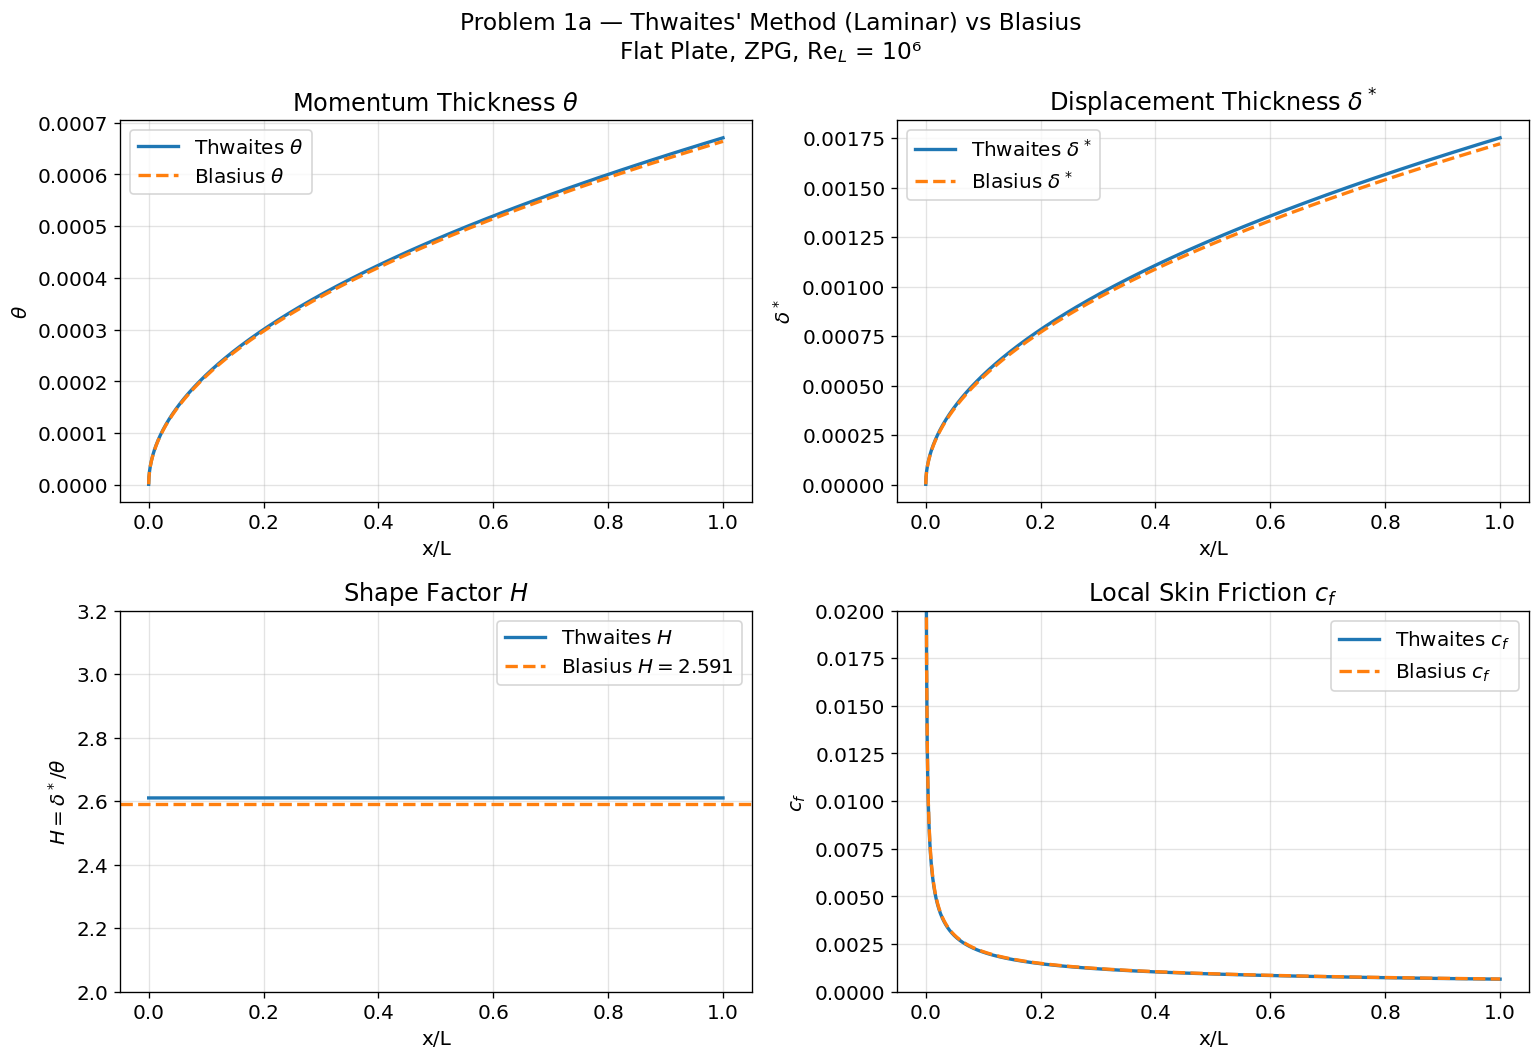


Thwaites Cf = 0.001454
Blasius  Cf = 0.001328
Relative error = 9.52%


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Problem 1a — Thwaites' Method (Laminar) vs Blasius\n"
             f"Flat Plate, ZPG, Re$_L$ = 10⁶", fontsize=14)

ax = axes[0, 0]
ax.plot(x, theta_thw,   label="Thwaites $\\theta$")
ax.plot(x, theta_blasius, '--', label="Blasius $\\theta$")
ax.set_xlabel('x/L'); ax.set_ylabel('$\\theta$')
ax.set_title('Momentum Thickness $\\theta$'); ax.legend()

ax = axes[0, 1]
ax.plot(x, dstar_thw,   label="Thwaites $\\delta^*$")
ax.plot(x, dstar_blasius, '--', label="Blasius $\\delta^*$")
ax.set_xlabel('x/L'); ax.set_ylabel('$\\delta^*$')
ax.set_title('Displacement Thickness $\\delta^*$'); ax.legend()

ax = axes[1, 0]
ax.plot(x, H_thw,    label="Thwaites $H$")
ax.axhline(2.591, ls='--', color='tab:orange', label="Blasius $H=2.591$")
ax.set_xlabel('x/L'); ax.set_ylabel('$H = \\delta^*/\\theta$')
ax.set_title('Shape Factor $H$'); ax.legend()
ax.set_ylim([2.0, 3.2])

ax = axes[1, 1]
ax.plot(x, cf_thw,    label="Thwaites $c_f$")
ax.plot(x, cf_blasius, '--', label="Blasius $c_f$")
ax.set_ylim([0, 0.02])
ax.set_xlabel('x/L'); ax.set_ylabel('$c_f$')
ax.set_title('Local Skin Friction $c_f$'); ax.legend()

plt.tight_layout()
plt.savefig('/Users/erwinpoussi/Documents/school projects/AA200/Head_thwaites_BL_integration_method/figures/thwaites_vs_blasius.png', bbox_inches='tight')
plt.show()
print(f"\nThwaites Cf = {Cf_thw:.6f}")
print(f"Blasius  Cf = {Cf_blasius:.6f}")
print(f"Relative error = {abs(Cf_thw-Cf_blasius)/Cf_blasius*100:.2f}%")

Overall the results between Thwaites and Blasius for a ZPG are consistent 

### 6.2 Head's Method (Turbulent) vs Blasius and Schlichting

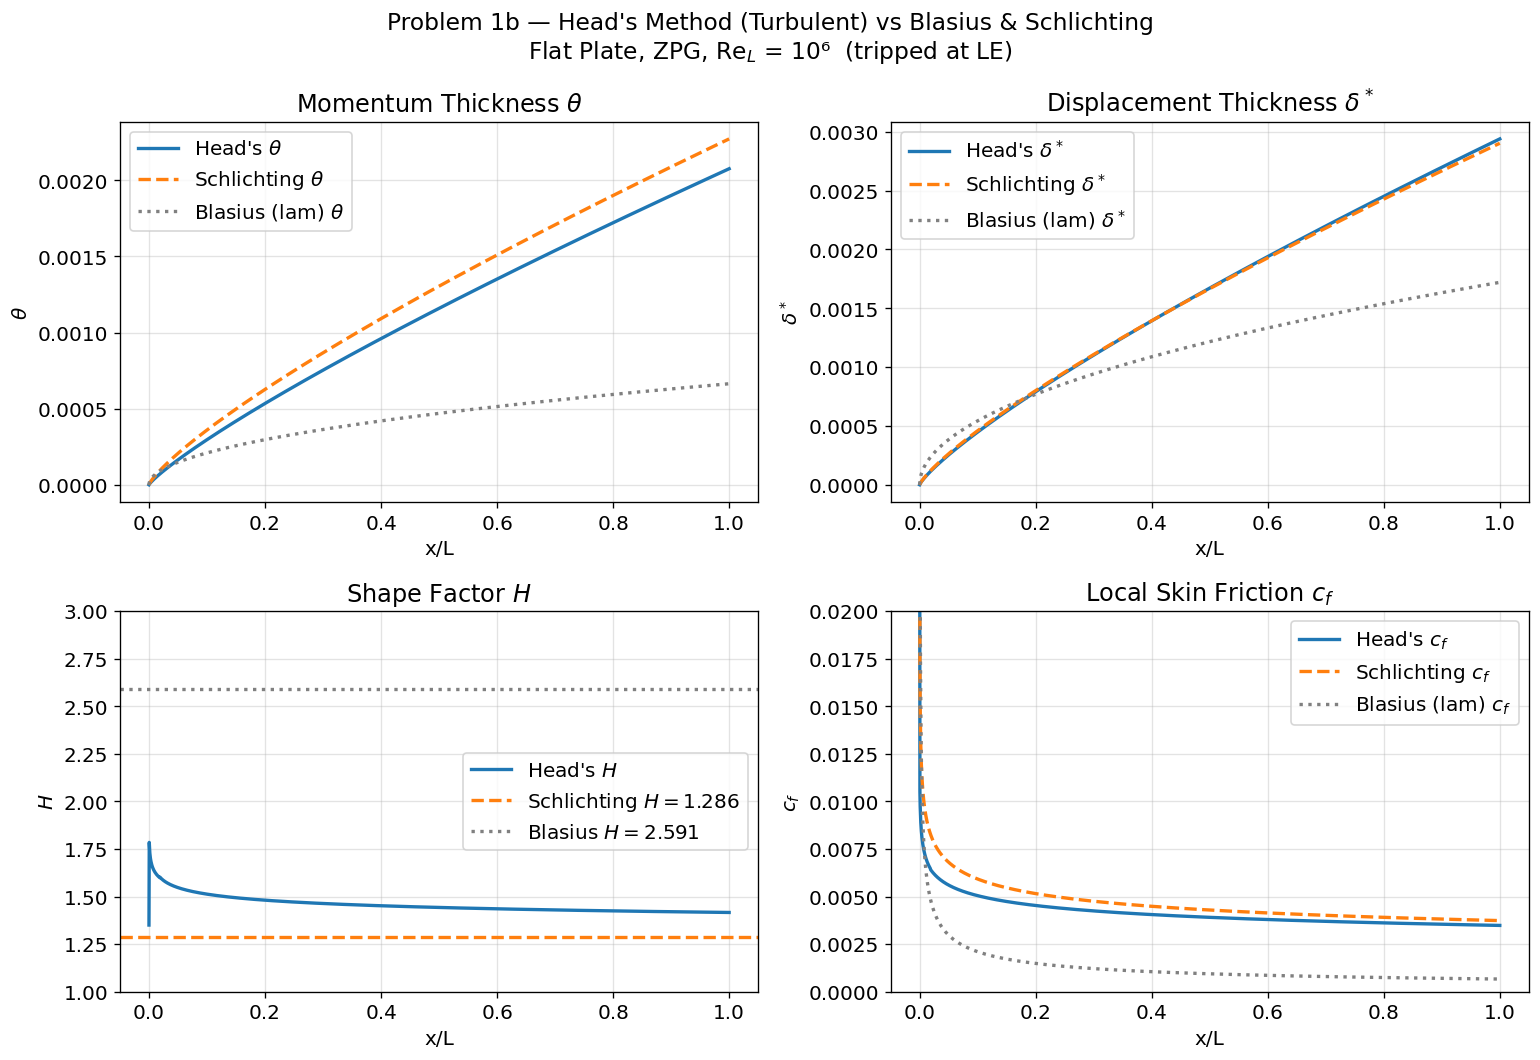


Head's      Cf = 0.004154
Schlichting Cf = 0.004669
Relative error = 11.03%


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Problem 1b — Head's Method (Turbulent) vs Blasius & Schlichting\n"
             f"Flat Plate, ZPG, Re$_L$ = 10⁶  (tripped at LE)", fontsize=14)

ax = axes[0, 0]
ax.plot(x, theta_head,  label="Head's $\\theta$")
ax.plot(x, theta_schl,  '--', label="Schlichting $\\theta$")
ax.plot(x, theta_blasius, ':', color='gray', label="Blasius (lam) $\\theta$")
ax.set_xlabel('x/L'); ax.set_ylabel('$\\theta$')
ax.set_title('Momentum Thickness $\\theta$'); ax.legend()

ax = axes[0, 1]
ax.plot(x, dstar_head,  label="Head's $\\delta^*$")
ax.plot(x, dstar_schl,  '--', label="Schlichting $\\delta^*$")
ax.plot(x, dstar_blasius, ':', color='gray', label="Blasius (lam) $\\delta^*$")
ax.set_xlabel('x/L'); ax.set_ylabel('$\\delta^*$')
ax.set_title('Displacement Thickness $\\delta^*$'); ax.legend()

ax = axes[1, 0]
ax.plot(x, H_head,   label="Head's $H$")
ax.axhline(1.286, ls='--', color='tab:orange', label="Schlichting $H=1.286$")
ax.axhline(2.591, ls=':', color='gray', label="Blasius $H=2.591$")
ax.set_xlabel('x/L'); ax.set_ylabel('$H$')
ax.set_title('Shape Factor $H$'); ax.legend()
ax.set_ylim([1.0, 3.0])

ax = axes[1, 1]
ax.plot(x, cf_head,   label="Head's $c_f$")
ax.plot(x, cf_schl,   '--', label="Schlichting $c_f$")
ax.plot(x, cf_blasius, ':', color='gray', label="Blasius (lam) $c_f$")
ax.set_ylim([0, 0.02])
ax.set_xlabel('x/L'); ax.set_ylabel('$c_f$')
ax.set_title('Local Skin Friction $c_f$'); ax.legend()

plt.tight_layout()
plt.savefig('/Users/erwinpoussi/Documents/school projects/AA200/Head_thwaites_BL_integration_method/figures/heads_vs_schlichting_blasius.png', bbox_inches='tight')
plt.show()
print(f"\nHead's      Cf = {Cf_head:.6f}")
print(f"Schlichting Cf = {Cf_schl:.6f}")
print(f"Relative error = {abs(Cf_head-Cf_schl)/Cf_schl*100:.2f}%")

### 6.3 Combined Comparison: Laminar vs Turbulent

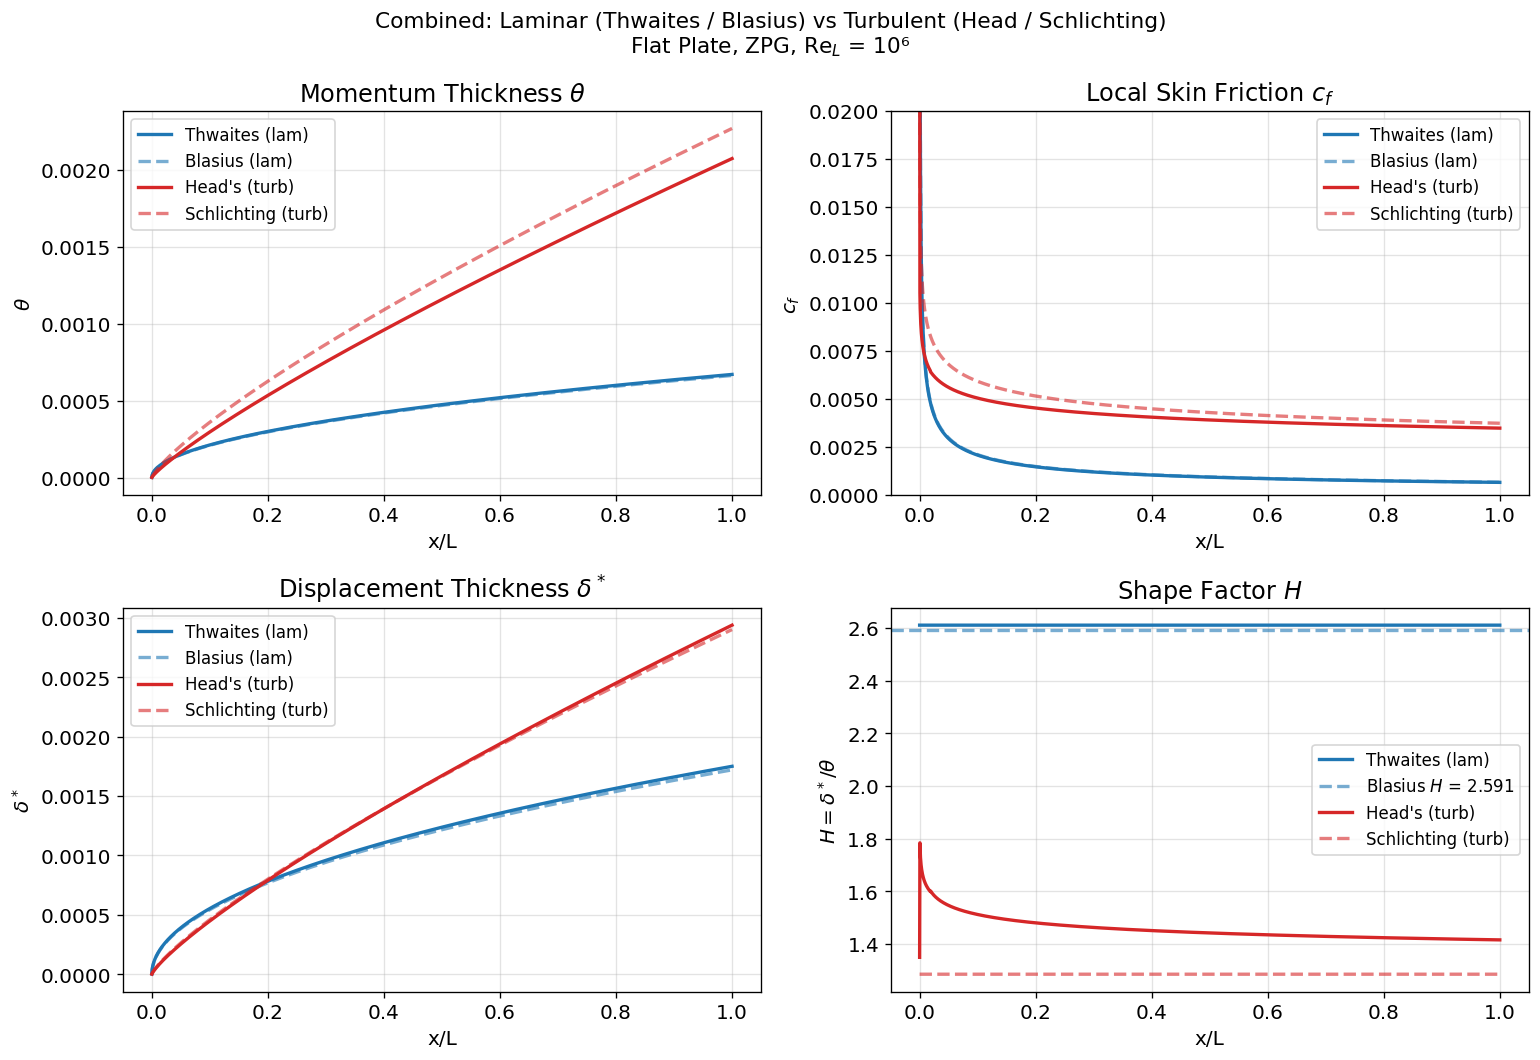

In [24]:

import os
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Combined: Laminar (Thwaites / Blasius) vs Turbulent (Head / Schlichting)\n"
             "Flat Plate, ZPG, Re$_L$ = 10⁶", fontsize=13)

# ── Momentum Thickness θ ──
ax = axes[0, 0]
ax.plot(x, theta_thw,    color='tab:blue',              label="Thwaites (lam)")
ax.plot(x, theta_blasius, '--', color='tab:blue',  alpha=0.6, label="Blasius (lam)")
ax.plot(x, theta_head,   color='tab:red',               label="Head's (turb)")
ax.plot(x, theta_schl,   '--', color='tab:red',   alpha=0.6, label="Schlichting (turb)")
ax.set_xlabel('x/L'); ax.set_ylabel('$\\theta$')
ax.set_title('Momentum Thickness $\\theta$'); ax.legend(fontsize=10)

# ── Local Skin Friction cf ──
ax = axes[0, 1]
ax.plot(x, cf_thw,    color='tab:blue',              label="Thwaites (lam)")
ax.plot(x, cf_blasius, '--', color='tab:blue', alpha=0.6, label="Blasius (lam)")
ax.plot(x, cf_head,   color='tab:red',               label="Head's (turb)")
ax.plot(x, cf_schl,   '--', color='tab:red',  alpha=0.6, label="Schlichting (turb)")
ax.set_ylim([0, 0.02])
ax.set_xlabel('x/L'); ax.set_ylabel('$c_f$')
ax.set_title('Local Skin Friction $c_f$'); ax.legend(fontsize=10)

# ── Displacement Thickness δ* ──
ax = axes[1, 0]
ax.plot(x, dstar_thw,    color='tab:blue',              label="Thwaites (lam)")
ax.plot(x, dstar_blasius, '--', color='tab:blue', alpha=0.6, label="Blasius (lam)")
ax.plot(x, dstar_head,   color='tab:red',               label="Head's (turb)")
ax.plot(x, dstar_schl,   '--', color='tab:red',  alpha=0.6, label="Schlichting (turb)")
ax.set_xlabel('x/L'); ax.set_ylabel('$\\delta^*$')
ax.set_title('Displacement Thickness $\\delta^*$'); ax.legend(fontsize=10)

# ── Shape Factor H ──
ax = axes[1, 1]
ax.plot(x, H_thw,    color='tab:blue',              label="Thwaites (lam)")
ax.axhline(H_blasius[-1], ls='--', color='tab:blue', alpha=0.6, label=f"Blasius $H$ = {H_blasius[-1]:.3f}")
ax.plot(x, H_head,   color='tab:red',               label="Head's (turb)")
ax.plot(x, H_schl,   '--', color='tab:red',  alpha=0.6, label="Schlichting (turb)")
ax.set_xlabel('x/L'); ax.set_ylabel('$H = \\delta^*/\\theta$')
ax.set_title('Shape Factor $H$'); ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../figures/combined_lam_turb.png', bbox_inches='tight')
plt.show()

---
## 7. Summary 

In [25]:
# ── Results Table ──
print("="*72)
print(f"{'Method':<22} {'Cf':>10} {'theta(L)':>12} {'delta*(L)':>12} {'H(L)':>8}")
print("-"*72)
print(f"{'Blasius (laminar)':<22} {Cf_blasius:>10.6f} {theta_blasius[-1]:>12.6f} {dstar_blasius[-1]:>12.6f} {H_blasius[-1]:>8.4f}")
print(f"{'Thwaites (laminar)':<22} {Cf_thw:>10.6f} {theta_thw[-1]:>12.6f} {dstar_thw[-1]:>12.6f} {H_thw[-1]:>8.4f}")
print("-"*72)
print(f"{'Schlichting (turb.)':<22} {Cf_schl:>10.6f} {theta_schl[-1]:>12.6f} {dstar_schl[-1]:>12.6f} {H_schl[-1]:>8.4f}")
print(f"{'Head (turbulent)':<22} {Cf_head:>10.6f} {theta_head[-1]:>12.6f} {dstar_head[-1]:>12.6f} {H_head[-1]:>8.4f}")
print("="*72)

# ── Accuracy ──
print("\n─── Accuracy checks ────────────────────────────────────────────────────")
print(f"  Thwaites vs Blasius   →  Cf={abs(Cf_thw-Cf_blasius)/Cf_blasius*100:.2f}%  "
      f"θ={abs(theta_thw[-1]-theta_blasius[-1])/theta_blasius[-1]*100:.2f}%  "
      f"H={abs(H_thw[-1]-H_blasius[-1])/H_blasius[-1]*100:.2f}%")
print(f"  Head's vs Schlichting →  Cf={abs(Cf_head-Cf_schl)/Cf_schl*100:.2f}%  "
      f"θ={abs(theta_head[-1]-theta_schl[-1])/theta_schl[-1]*100:.2f}%  "
      f"H={abs(H_head[-1]-H_schl[-1])/H_schl[-1]*100:.2f}%")
print("  → Both integral methods show close agreement with their references.\n")

# ── Laminar vs Turbulent ──
print("─── Laminar vs Turbulent gap (Blasius vs Head) ─────────────────────────")
print(f"  Cf    {Cf_head/Cf_blasius:.2f}x higher  |  "
      f"θ  {theta_head[-1]/theta_blasius[-1]:.2f}x thicker  |  "
      f"δ* {dstar_head[-1]/dstar_blasius[-1]:.2f}x thicker")
print(f"  H: {H_blasius[-1]:.3f} (lam) → {H_head[-1]:.3f} (turb)  "
      f"→ lower H confirms fuller turbulent velocity profile")
print("  → Large gap: turbulent BL grows faster with significantly higher")
print("    skin friction, thicker BL, but a fuller (lower H) profile.")
print("="*72)

Method                         Cf     theta(L)    delta*(L)     H(L)
------------------------------------------------------------------------
Blasius (laminar)        0.001328     0.000664     0.001721   2.5910
Thwaites (laminar)       0.001454     0.000671     0.001751   2.6100
------------------------------------------------------------------------
Schlichting (turb.)      0.004669     0.002271     0.002902   1.2860
Head (turbulent)         0.004154     0.002076     0.002939   1.4162

─── Accuracy checks ────────────────────────────────────────────────────
  Thwaites vs Blasius   →  Cf=9.52%  θ=1.03%  H=0.73%
  Head's vs Schlichting →  Cf=11.03%  θ=8.62%  H=10.13%
  → Both integral methods show close agreement with their references.

─── Laminar vs Turbulent gap (Blasius vs Head) ─────────────────────────
  Cf    3.13x higher  |  θ  3.13x thicker  |  δ* 1.71x thicker
  H: 2.591 (lam) → 1.416 (turb)  → lower H confirms fuller turbulent velocity profile
  → Large gap: turbulent BL grow